### How `norminv` works
Edit the numbers marked `👈` and re-run.

norminv(0.95) = 1.6449


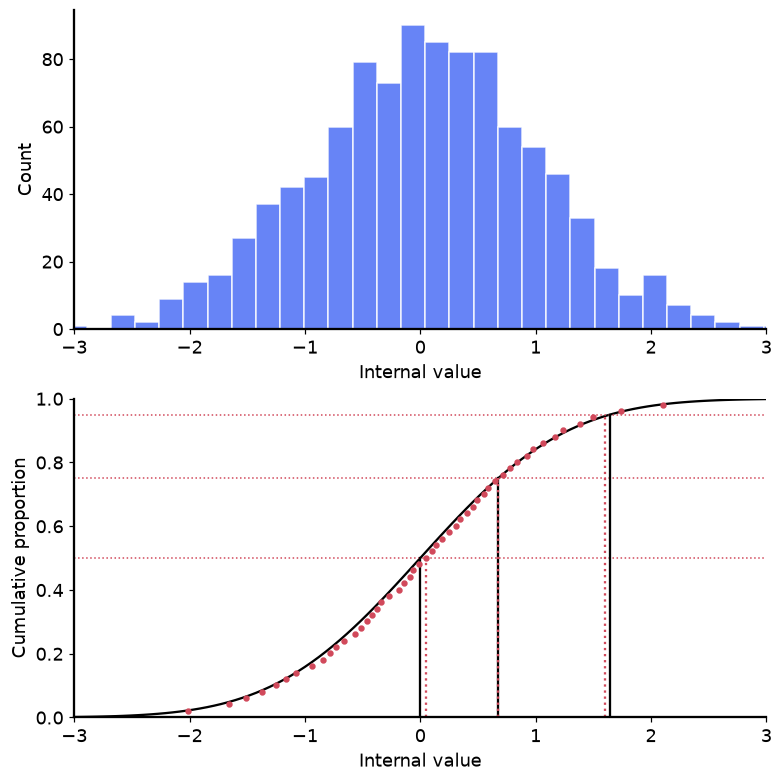

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
NOISE  = "#4c6ef5"   # signal-absent (noise) trials
SIGNAL = "#d1495b"   # signal-present trials
CRIT   = "#333333"   # criterion / theory lines

from scipy.stats import norm

# the normal (standard) gaussian: mean 0, sd 1
nsamples = 1000       # 👈 try more or fewer samples
rng = np.random.default_rng()
samples = rng.normal(0, 1, nsamples)
samples_sorted = np.sort(samples)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), constrained_layout=True)

# top: the histogram
ax1.hist(samples, bins=30, color=NOISE, alpha=0.85, edgecolor="white")
ax1.set(xlim=(-3, 3), xlabel="Internal value", ylabel="Count")

# bottom: cumulative — sampled (red dots) vs theoretical normcdf (black line)
idx = np.arange(0, nsamples, 20)
ax2.scatter(samples_sorted[idx], (idx + 1) / nsamples, 10, color=SIGNAL, zorder=3)
xs = np.linspace(-3, 3, 100)
ax2.plot(xs, norm.cdf(xs), color="k")
ax2.set(xlim=(-3, 3), ylim=(0, 1), xlabel="Internal value", ylabel="Cumulative proportion")

# norminv examples: the x-value reached at 50%, 75%, 95%
for p in (0.5, 0.75, 0.95):
    theoretical = norm.ppf(p)                       # norminv(p)
    sampled = samples_sorted[int(nsamples * p)]     # the matching sorted sample
    ax2.plot([-3, 3], [p, p], color=SIGNAL, ls=":", lw=1)
    ax2.plot([theoretical, theoretical], [0, p], color="k")
    ax2.plot([sampled, sampled], [0, p], color=SIGNAL, ls=":", lw=1.5)

print("norminv(0.95) =", round(float(norm.ppf(0.95)), 4))
plt.show()
